In [ ]:
# 1. Re-install & Login
!pip install -q kagglehub ultralytics
import kagglehub, os, yaml
from ultralytics import YOLO
kagglehub.login()

# 2. Re-download and Fix the Path (Absolute Path Fix)
path = kagglehub.dataset_download("sjqqiu/container-damage-detection")
actual_data_root = os.path.join(path, 'images')

config = {
    'path': actual_data_root,
    'train': 'train',
    'val': 'val',
    'test': 'test',
    'nc': 4,
    'names': ['dent', 'hole', 'rust', 'scratch']
}

with open('/content/fixed_data.yaml', 'w') as f:
    yaml.dump(config, f)

# 3. Start the High-Speed GPU Training
model = YOLO('yolov8m.pt') # This triggers the auto-download!
model.train(data='/content/fixed_data.yaml', epochs=25, imgsz=640, batch=16, device=0)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 68.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 364M/364M [00:25<00:00, 15.2MB/s]

Extracting files...


Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/fixed_data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, pl

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e57bd6200e0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

In [ ]:
import os

# Use the root path we discovered during training
test_path = os.path.join(actual_data_root, 'test')

# Let's verify the files are actually there
if os.path.exists(test_path):
    print(f"✅ Found test folder at: {test_path}")
    print("Sample images:", os.listdir(test_path)[:3])
else:
    print("❌ Still missing. Let's check the parent directory:")
    print(os.listdir(os.path.dirname(actual_data_root)))

✅ Found test folder at: /root/.cache/kagglehub/datasets/sjqqiu/container-damage-detection/versions/1/images/test
Sample images: ['ContainerDamage_3313.jpg', 'ContainerDamage_1523.jpg', 'ContainerDamage_3276.jpg']


In [ ]:
# Run prediction on the real test path
# We'll limit it to 5 images so it's fast
results = model.predict(source=test_path, save=True, conf=0.25, max_det=10)

# Locate the output
print("\n🚀 Prediction complete!")
print("Your visual results are saved in: /content/runs/detect/predict/")


image 1/380 /root/.cache/kagglehub/datasets/sjqqiu/container-damage-detection/versions/1/images/test/ContainerDamage_1011.jpg: 640x640 1 hole, 37.0ms
image 2/380 /root/.cache/kagglehub/datasets/sjqqiu/container-damage-detection/versions/1/images/test/ContainerDamage_1013.jpg: 640x640 1 hole, 65.9ms
image 3/380 /root/.cache/kagglehub/datasets/sjqqiu/container-damage-detection/versions/1/images/test/ContainerDamage_1028.jpg: 640x640 (no detections), 43.9ms
image 4/380 /root/.cache/kagglehub/datasets/sjqqiu/container-damage-detection/versions/1/images/test/ContainerDamage_1035.jpg: 640x640 (no detections), 64.9ms
image 5/380 /root/.cache/kagglehub/datasets/sjqqiu/container-damage-detection/versions/1/images/test/ContainerDamage_1045.jpg: 640x640 1 hole, 53.9ms
image 6/380 /root/.cache/kagglehub/datasets/sjqqiu/container-damage-detection/versions/1/images/test/ContainerDamage_1061.jpg: 640x640 (no detections), 40.0ms
image 7/380 /root/.cache/kagglehub/datasets/sjqqiu/container-damage-dete

In [5]:
from google.colab import files
import os

print("Select your finetuningdata.zip file:")
uploaded = files.upload()

# Move it to a clean spot if needed
if os.path.exists('finetuningdata.zip'):
    print("✅ Upload complete!")

Select your finetuningdata.zip file:


Saving finetuningdata.zip to finetuningdata.zip
✅ Upload complete!


In [7]:
import os
import yaml

# CHANGE THIS to whatever folder the 'find' command showed you
data_root = '/content/dataset'

# Let's verify the labels and images exist
train_img_path = os.path.join(data_root, 'train/images')
if os.path.exists(train_img_path):
    print(f"✅ Found images at: {train_img_path}")
else:
    print(f"❌ Still can't find 'train/images'. Current content: {os.listdir(data_root)}")

# Update/Create the YAML for this specific local data
config = {
    'path': data_root,
    'train': 'train/images',
    'val': 'val/images',
    'test': 'test/images',
    'nc': 4,
    'names': ['dent', 'hole', 'rust', 'scratch']
}

with open('/content/local_data.yaml', 'w') as f:
    yaml.dump(config, f)

✅ Found images at: /content/dataset/train/images


In [8]:
import yaml

# The verified root of your unzipped data
data_root = '/content/dataset'

config = {
    'path': data_root,
    'train': 'train/images',   # YOLO looks for /labels in a sibling folder automatically
    'val': 'valid/images',     # Check if your folder is named 'valid' or 'val'
    'test': 'test/images',
    'nc': 4,
    'names': ['dent', 'hole', 'rust', 'scratch']
}

with open('/content/local_data.yaml', 'w') as f:
    yaml.dump(config, f)

print("✅ Local YAML generated at /content/local_data.yaml")

✅ Local YAML generated at /content/local_data.yaml


In [10]:
from ultralytics import YOLO

# 1. Load the Medium model again
model = YOLO('yolov8m.pt')

# 2. Train on the T4 GPU
# We're using 50 epochs now for better convergence
model.train(
    data='/content/local_data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    name='container_local_finetune'
)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/local_data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=container_local_finetune2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100,

KeyboardInterrupt: 

In [12]:
import os

# 1. Create a fresh directory
!rm -rf /content/dataset
!mkdir -p /content/dataset

# 2. Unzip the file
# This assumes the file is named 'finetuningdata.zip' in your sidebar
!unzip -q /content/finetuningdata.zip -d /content/dataset

# 3. Check the immediate contents
print("Items in /content/dataset:")
print(os.listdir('/content/dataset'))

Items in /content/dataset:
['data.yaml', 'test', 'valid', 'train', 'README.roboflow.txt', 'README.dataset.txt']


In [13]:
import yaml

# 1. Load the existing yaml
with open('/content/dataset/data.yaml', 'r') as f:
    config = yaml.safe_load(f)

# 2. Force the paths to match Colab's structure
config['path'] = '/content/dataset'
config['train'] = 'train/images'
config['val'] = 'valid/images'
config['test'] = 'test/images'

# 3. Save it back
with open('/content/dataset/data.yaml', 'w') as f:
    yaml.dump(config, f)

print("--- Updated YAML Content ---")
print(yaml.dump(config))

--- Updated YAML Content ---
names:
- Deframe
- Dent
- Hole
- Minor-Dent
- Rust
nc: 5
path: /content/dataset
roboflow:
  license: CC BY 4.0
  project: container-damage-detection-uekkr
  url: https://universe.roboflow.com/project-gvpak/container-damage-detection-uekkr/dataset/2
  version: 2
  workspace: project-gvpak
test: test/images
train: train/images
val: valid/images



In [14]:
from ultralytics import YOLO

# 1. Load the Medium model (more neurons for 5 classes)
model = YOLO('yolov8m.pt')

# 2. Start the Training on the T4 GPU
# We point to the yaml we just updated inside the dataset folder
model.train(
    data='/content/dataset/data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    name='container_local_final'
)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=container_local_final, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, p

KeyboardInterrupt: 

In [15]:
from ultralytics import YOLO

# 1. Load the 'Small' YOLOv5 brain (Better for Jetson Nano)
model = YOLO('yolov5s.pt')

# 2. Re-start the 50-epoch training
model.train(
    data='/content/dataset/data.yaml',
    epochs=50,
    imgsz=416,   # Pro-Tip: Reducing from 640 to 416 makes it 2x faster on Jetson!
    batch=32,    # v5s is smaller, so we can double the batch size for faster training
    device=0,
    name='container_jetson_yolov5s'
)

PRO TIP 💡 Replace 'model=yolov5s.pt' with new 'model=yolov5su.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.com/ultralytics/yolov5.

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, l

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e57b4fe1880>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        

✅ Model loaded successfully!
👇 Click 'Choose Files' to upload an image:


Saving demo1.jpg to demo1.jpg

0: 256x416 1 Deframe, 3 Dents, 68.4ms
Speed: 1.7ms preprocess, 68.4ms inference, 1.6ms postprocess per image at shape (1, 3, 256, 416)


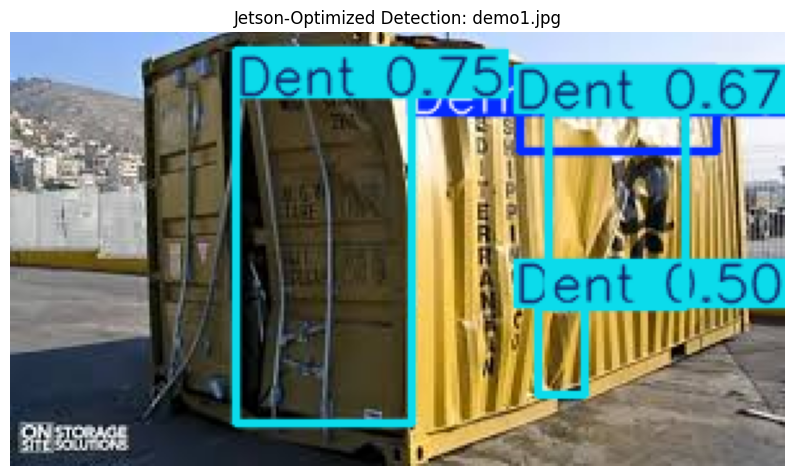

In [19]:
from google.colab import files
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import os

# --- PASTE YOUR PATH FROM STEP 1 HERE ---
# Example: '/content/runs/detect/train/weights/best.pt'
model_path = '/content/runs/detect/container_jetson_yolov5s/weights/best.pt'

if not os.path.exists(model_path):
    print(f"❌ Error: Could not find model at {model_path}")
    print("Check the output of Step 1 and update the path!")
else:
    model = YOLO(model_path)
    print("✅ Model loaded successfully!")

    def run_inference():
        print("👇 Click 'Choose Files' to upload an image:")
        uploaded = files.upload()

        for filename in uploaded.keys():
            img = Image.open(filename)
            results = model.predict(source=img, conf=0.25, imgsz=416)

            # Plot and Show
            res_plotted = results[0].plot()
            plt.figure(figsize=(10, 10))
            plt.imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))
            plt.title(f"Jetson-Optimized Detection: {filename}")
            plt.axis('off')
            plt.show()

    run_inference()

In [21]:
import os

# Define the path to your labels
label_dirs = ['/content/dataset/train/labels', '/content/dataset/valid/labels', '/content/dataset/test/labels']

for d in label_dirs:
    for filename in os.listdir(d):
        if filename.endswith('.txt'):
            path = os.path.join(d, filename)
            with open(path, 'r') as f:
                lines = f.readlines()

            with open(path, 'w') as f:
                for line in lines:
                    parts = line.split()
                    class_id = int(parts[0])
                    # If it's NOT a Deframe (0), we keep it but subtract 1 to fill the gap
                    if class_id > 0:
                        new_id = class_id - 1
                        f.write(f"{new_id} {' '.join(parts[1:])}\n")
                    # If it IS 0 (Deframe), we just don't write it to the file!

print("✅ All 'Deframe' labels removed and IDs shifted!")

✅ All 'Deframe' labels removed and IDs shifted!


In [22]:
import yaml

config = {
    'path': '/content/dataset',
    'train': 'train/images',
    'val': 'valid/images',
    'test': 'test/images',
    'nc': 4,
    'names': ['Dent', 'Hole', 'Minor-Dent', 'Rust'] # Deframe is gone!
}

with open('/content/dataset/data_no_deframe.yaml', 'w') as f:
    yaml.dump(config, f)

In [23]:
from google.colab import files

# Using the path you discovered earlier
files.download('/content/runs/detect/container_jetson_yolov5s/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
from google.colab import files
import os

print("👇 Select your NEW dataset ZIP file:")
uploaded = files.upload()

# Grab the exact name of the file you uploaded
zip_filename = list(uploaded.keys())[0]

# 1. Create a safe staging folder
!mkdir -p /content/new_data_temp

# 2. Extract the contents quietly (-q)
!unzip -q /content/{zip_filename} -d /content/new_data_temp

print(f"\n✅ Successfully unzipped {zip_filename} to /content/new_data_temp")

# 3. Let's see what's inside
print("\nContents of the new folder:")
!ls /content/new_data_temp

👇 Select your NEW dataset ZIP file:


Saving finetuning2.zip to finetuning2.zip
replace /content/new_data_temp/data.yaml? [y]es, [n]o, [A]ll, [N]one, [r]ename: A

✅ Successfully unzipped finetuning2.zip to /content/new_data_temp

Contents of the new folder:
data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [26]:
from ultralytics import YOLO
import os

# The path to your current best Jetson model
model_path = '/content/runs/detect/container_jetson_yolov5s/weights/best.pt'

if os.path.exists(model_path):
    print("✅ Model file found! Loading brain...\n")
    model = YOLO(model_path)

    print("🧠 MODEL ARCHITECTURE & INFO:")
    print("-" * 30)
    # This prints the layer count, parameter count, and size
    model.info()

    print("\n🏷️ CURRENT CLASSES IT KNOWS:")
    print("-" * 30)
    # This prints the exact ID-to-Name mapping
    for class_id, class_name in model.names.items():
        print(f"ID {class_id}: {class_name}")
else:
    print(f"❌ Could not find model at {model_path}.")
    print("If you restarted Colab, check the folder icon on the left to find your runs/detect/ folder!")

✅ Model file found! Loading brain...

🧠 MODEL ARCHITECTURE & INFO:
------------------------------
YOLOv5s summary: 154 layers, 9,124,127 parameters, 0 gradients, 24.1 GFLOPs

🏷️ CURRENT CLASSES IT KNOWS:
------------------------------
ID 0: Deframe
ID 1: Dent
ID 2: Hole
ID 3: Minor-Dent
ID 4: Rust


In [27]:
!cat /content/new_data_temp/data.yaml

path: ../datasets/roboflow

train: train/images
val: valid/images
test: test/images

nc: 5
names: ['Deframe', 'Dent', 'Hole', 'Minor-Dent', 'Rust']

In [28]:
import yaml

yaml_path = '/content/new_data_temp/data.yaml'

with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

# Update to point to your unzipped folder
data['path'] = '/content/new_data_temp'
data['train'] = 'train/images'
data['val'] = 'valid/images'
data['test'] = 'test/images'

with open(yaml_path, 'w') as f:
    yaml.dump(data, f)

print("✅ YAML paths successfully updated for Colab!")

✅ YAML paths successfully updated for Colab!


In [29]:
from ultralytics import YOLO

# 1. Load your existing smart brain
model = YOLO('/content/runs/detect/container_jetson_yolov5s/weights/best.pt')

# 2. Train it on the new dataset
model.train(
    data='/content/new_data_temp/data.yaml',
    epochs=30,   # 30 epochs is usually perfect for fine-tuning
    imgsz=416,   # Keep the Jetson Nano speed resolution!
    batch=32,
    device=0,
    name='jetson_v5s_finetuned_v2' # New folder name so we don't overwrite the old one
)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/new_data_temp/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/runs/detect/container_jetson_yolov5s/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=jetson_v5s_finetuned_v2, nbs=64, nms=False, opset=None, optimiz

/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:839: RuntimeWarning: Mean of empty slice.
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/30      3.33G          0     0.2842          0          0        416: 100% ━━━━━━━━━━━━ 28/28 2.4it/s 11.9s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 3.8it/s 1.1s
                   all        256          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, cannot compute metrics without labels


/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:839: RuntimeWarning: Mean of empty slice.
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/30      3.88G          0   0.008789          0          0        416: 100% ━━━━━━━━━━━━ 28/28 3.0it/s 9.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 4.0it/s 1.0s
                   all        256          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, cannot compute metrics without labels


/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:839: RuntimeWarning: Mean of empty slice.
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       4/30      3.88G          0  1.022e-07          0          0        416: 100% ━━━━━━━━━━━━ 28/28 2.9it/s 9.8s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 4.0it/s 1.0s
                   all        256          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, cannot compute metrics without labels


/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:839: RuntimeWarning: Mean of empty slice.
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       5/30      3.88G          0          0          0          0        416: 39% ━━━━╸─────── 11/28 5.9it/s 3.5s<2.9s


KeyboardInterrupt: 

In [30]:
import os

base_path = '/content/new_data_temp/train'

print("🔍 FOLDER DIAGNOSTIC:")
print("-" * 25)

# Check Images
if os.path.exists(os.path.join(base_path, 'images')):
    img_count = len(os.listdir(os.path.join(base_path, 'images')))
    print(f"✅ Images found: {img_count}")
else:
    print("❌ 'images' folder is missing!")

# Check Labels
if os.path.exists(os.path.join(base_path, 'labels')):
    lbl_count = len(os.listdir(os.path.join(base_path, 'labels')))
    print(f"✅ Labels found: {lbl_count}")
else:
    print("❌ 'labels' folder is missing! (This is why it crashed)")

    # If missing, let's see what is actually in the train folder
    print(f"\nContents of {base_path}:")
    print(os.listdir(base_path))

🔍 FOLDER DIAGNOSTIC:
-------------------------
✅ Images found: 894
❌ 'labels' folder is missing! (This is why it crashed)

Contents of /content/new_data_temp/train:
['labels.cache', 'labelTxt', 'images']


In [31]:
import os

base_dir = '/content/new_data_temp'
splits = ['train', 'valid', 'test']

print("🔧 INITIATING SURGERY...")
for split in splits:
    split_dir = os.path.join(base_dir, split)
    if os.path.exists(split_dir):
        # 1. Rename the folder
        old_labels = os.path.join(split_dir, 'labelTxt')
        new_labels = os.path.join(split_dir, 'labels')

        if os.path.exists(old_labels):
            os.rename(old_labels, new_labels)
            print(f"✅ Fixed: Renamed 'labelTxt' to 'labels' in {split} folder.")

        # 2. Delete the poisonous cache file
        cache_file = os.path.join(split_dir, 'labels.cache')
        if os.path.exists(cache_file):
            os.remove(cache_file)
            print(f"🗑️ Cleaned: Deleted corrupt {split}/labels.cache.")

print("\n🚀 Surgery complete. Data is now YOLO-compliant!")

🔧 INITIATING SURGERY...
✅ Fixed: Renamed 'labelTxt' to 'labels' in train folder.
🗑️ Cleaned: Deleted corrupt train/labels.cache.
✅ Fixed: Renamed 'labelTxt' to 'labels' in valid folder.
🗑️ Cleaned: Deleted corrupt valid/labels.cache.
✅ Fixed: Renamed 'labelTxt' to 'labels' in test folder.

🚀 Surgery complete. Data is now YOLO-compliant!


In [32]:
from ultralytics import YOLO

# 1. Load your existing Jetson-ready brain
model = YOLO('/content/runs/detect/container_jetson_yolov5s/weights/best.pt')

# 2. Train it on the FIXED new dataset
model.train(
    data='/content/new_data_temp/data.yaml',
    epochs=30,
    imgsz=416,
    batch=32,
    device=0,
    name='jetson_v5s_finetuned_v2'
)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/new_data_temp/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/runs/detect/container_jetson_yolov5s/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=jetson_v5s_finetuned_v22, nbs=64, nms=False, opset=None, optimi

RuntimeError: No valid images found in /content/new_data_temp/train/labels.cache. Images with incorrectly formatted labels are ignored. See https://docs.ultralytics.com/datasets for dataset formatting guidance.

In [33]:
import os

lbl_dir = '/content/new_data_temp/train/labels'

# Make sure we delete the bad cache file again first!
cache_file = '/content/new_data_temp/train/labels.cache'
if os.path.exists(cache_file):
    os.remove(cache_file)

# Get the very first .txt file
try:
    all_labels = [f for f in os.listdir(lbl_dir) if f.endswith('.txt')]
    sample_label = all_labels[0]
    sample_label_path = os.path.join(lbl_dir, sample_label)

    print(f"📄 Looking inside: {sample_label}")
    print("-" * 40)
    with open(sample_label_path, 'r') as f:
        content = f.read()
        if not content.strip():
            print("[FILE IS EMPTY]")
        else:
            print(content)
    print("-" * 40)

except Exception as e:
    print(f"Error reading labels: {e}")

📄 Looking inside: 9_jpg.rf.cf072e973d3a631546a8d365241098bf.txt
----------------------------------------
612 87.00000000000006 419 87.00000000000006 419 236.00000000000006 612 236.00000000000006 Deframe 0
466 74.00000000000006 362 74.00000000000006 362 108.00000000000006 466 108.00000000000006 Minor-Dent 0
----------------------------------------


In [ ]:
from google.colab import files
from ultralytics import YOLO
import os

print("👇 Upload your perfectly formatted YOLOv5 ZIP:")
uploaded = files.upload()
zip_filename = list(uploaded.keys())[0]

# 1. Create a brand new, clean staging area
clean_dir = '/content/clean_dataset'
!mkdir -p {clean_dir}

# 2. Extract quietly and overwrite automatically
!unzip -o -q /content/{zip_filename} -d {clean_dir}
print(f"\n✅ Unzipped to {clean_dir}!")

# 3. Double-check the YAML path for Colab
yaml_path = f"{clean_dir}/data.yaml"
if os.path.exists(yaml_path):
    import yaml
    with open(yaml_path, 'r') as f:
        data = yaml.safe_load(f)

    # Force the paths to be correct for this Colab session
    data['path'] = clean_dir
    data['train'] = 'train/images'
    data['val'] = 'valid/images'

    with open(yaml_path, 'w') as f:
        yaml.dump(data, f)
    print("✅ YAML paths synced!")

# 4. IGNITION: Start the Fine-Tuning!
print("\n🚀 Starting Fine-Tuning with your Jetson-ready brain...")
model = YOLO('/content/runs/detect/container_jetson_yolov5s/weights/best.pt')

model.train(
    data=yaml_path,
    epochs=30,
    imgsz=416,
    batch=32,
    device=0,
    name='jetson_v5s_perfect_finetune'
)

👇 Upload your perfectly formatted YOLOv5 ZIP:


Saving finetuningv2.zip to finetuningv2.zip

✅ Unzipped to /content/clean_dataset!
✅ YAML paths synced!

🚀 Starting Fine-Tuning with your Jetson-ready brain...
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/clean_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/runs/de

In [35]:
from ultralytics import YOLO
import os

# 1. Point this to the folder of your interrupted run
# (If you used a different name in the last step, change it here!)
run_name = 'jetson_v5s_perfect_finetune'
rescued_model_path = f'/content/runs/detect/{run_name}/weights/best.pt'

if os.path.exists(rescued_model_path):
    print("✅ Rescued brain found! Loading...")
    model = YOLO(rescued_model_path)

    # 2. Run a validation test to see the final scores
    print("\n📊 Running final evaluation on the rescued model...")
    metrics = model.val()

    print("\n🎉 Rescue Complete! Your model is ready.")
else:
    print(f"❌ Could not find {rescued_model_path}")
    print("Run this to find your actual folder name: !ls /content/runs/detect/")

✅ Rescued brain found! Loading...

📊 Running final evaluation on the rescued model...
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv5s summary (fused): 85 layers, 9,113,471 parameters, 0 gradients, 23.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1283.3±584.3 MB/s, size: 65.0 KB)
val: Scanning /content/clean_dataset/valid/labels.cache... 256 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 256/256 71.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 3.1it/s 5.2s
                   all        256        527       0.67      0.521      0.561      0.398
               Deframe         23         26      0.588      0.385      0.516       0.34
                  Dent        146        168      0.701       0.88       0.83      0.668
                  Hole         14         17      0.884      0.448      0.517       0.32
            Minor-Dent        101        14

In [36]:
from ultralytics import YOLO
from google.colab import files
import matplotlib.pyplot as plt
import cv2
from PIL import Image

# 1. Load the Universal ONNX Engine
# Replace with your actual file path if it's different!
onnx_path = 'best.onnx'
model = YOLO(onnx_path)

print("✅ ONNX Model Loaded Successfully!")
print("👇 Upload an image to test the ONNX engine:")

# 2. Upload a test image
uploaded = files.upload()

for filename in uploaded.keys():
    img = Image.open(filename)

    # 3. Run the Inference (Keeping your Jetson settings!)
    # imgsz=416 ensures it processes at the exact speed the Nano expects
    results = model.predict(source=img, conf=0.25, imgsz=416)

    # 4. Visualize the output
    res_plotted = results[0].plot()

    plt.figure(figsize=(12, 12))
    plt.imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))
    plt.title(f"ONNX Inference: {filename}")
    plt.axis('off')
    plt.show()

    # Print a quick summary of what the ONNX model found
    print(f"\n🔍 ONNX Engine found {len(results[0].boxes)} issues in {filename}:")
    for box in results[0].boxes:
        class_id = int(box.cls[0])
        conf = float(box.conf[0])
        print(f"  - {model.names[class_id]} (Confidence: {conf:.2f})")

FileNotFoundError: 'best.onnx' does not exist

In [37]:
from ultralytics import YOLO
from google.colab import files
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import os

# 1. Point directly to the folder where YOLO saved the export
onnx_path = '/content/runs/detect/jetson_v5s_perfect_finetune/weights/best.onnx'

if not os.path.exists(onnx_path):
    print(f"❌ Error: Still can't find it at {onnx_path}.")
    print("Run this to find it: !find /content/runs/detect -name '*.onnx'")
else:
    model = YOLO(onnx_path)
    print("✅ ONNX Model Loaded Successfully!")
    print("👇 Upload an image to test the ONNX engine:")

    # 2. Upload a test image
    uploaded = files.upload()

    for filename in uploaded.keys():
        img = Image.open(filename)

        # 3. Run the Inference (Keeping your Jetson settings!)
        results = model.predict(source=img, conf=0.25, imgsz=416)

        # 4. Visualize the output
        res_plotted = results[0].plot()

        plt.figure(figsize=(10, 10))
        plt.imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))
        plt.title(f"ONNX Inference: {filename}")
        plt.axis('off')
        plt.show()

        # Print summary
        print(f"\n🔍 ONNX Engine found {len(results[0].boxes)} issues:")
        for box in results[0].boxes:
            class_id = int(box.cls[0])
            conf = float(box.conf[0])
            print(f"  - {model.names[class_id]} (Confidence: {conf:.2f})")

❌ Error: Still can't find it at /content/runs/detect/jetson_v5s_perfect_finetune/weights/best.onnx.
Run this to find it: !find /content/runs/detect -name '*.onnx'


In [38]:
!find /content/runs/detect -name "*.onnx"

In [39]:
from ultralytics import YOLO
from google.colab import files

# 1. Load the PyTorch brain we rescued earlier
model = YOLO('/content/runs/detect/jetson_v5s_perfect_finetune/weights/best.pt')

print("🔄 Translating PyTorch brain into Universal ONNX format...")

# 2. Export it! (imgsz=416 keeps it fast for the Jetson)
onnx_path = model.export(format='onnx', imgsz=416, dynamic=False)

print(f"\n✅ Export Complete! Your ONNX file is located at: {onnx_path}")

# 3. Automatically download it to your physical computer
files.download(onnx_path)

🔄 Translating PyTorch brain into Universal ONNX format...
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLOv5s summary (fused): 85 layers, 9,113,471 parameters, 0 gradients, 23.8 GFLOPs

PyTorch: starting from '/content/runs/detect/jetson_v5s_perfect_finetune/weights/best.pt' with input shape (1, 3, 416, 416) BCHW and output shape(s) (1, 9, 3549) (17.6 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 525ms
Prepared 4 packages in 13.28s
Installed 4 packages in 353ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime-gpu==1.24.4
 + onnxslim==0.1.90

requirements: AutoUpdate success ✅ 15.2s
WARNING ⚠️ requirements: Restart runtime or rerun command for up

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

🔍 Searching for your ONNX brain...
✅ Found and loaded ONNX model at: /content/runs/detect/jetson_v5s_perfect_finetune/weights/best.onnx

👇 Click 'Choose Files' below and select your 3 test images:


Saving demo2.webp to demo2 (1).webp

⚙️ Processing through ONNX Engine...

Loading /content/runs/detect/jetson_v5s_perfect_finetune/weights/best.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.24.4 with CUDAExecutionProvider

0: 416x416 4 Dents, 2 Holes, 1 Minor-Dent, 2 Rusts, 11.9ms
Speed: 2.2ms preprocess, 11.9ms inference, 2.2ms postprocess per image at shape (1, 3, 416, 416)
🖼️ Results for demo2 (1).webp: Found 9 issues.
  - Hole (Confidence: 0.72)
  - Dent (Confidence: 0.56)
  - Dent (Confidence: 0.48)
  - Hole (Confidence: 0.44)
  - Dent (Confidence: 0.41)
  - Rust (Confidence: 0.31)
  - Dent (Confidence: 0.30)
  - Rust (Confidence: 0.29)
  - Minor-Dent (Confidence: 0.28)
------------------------------


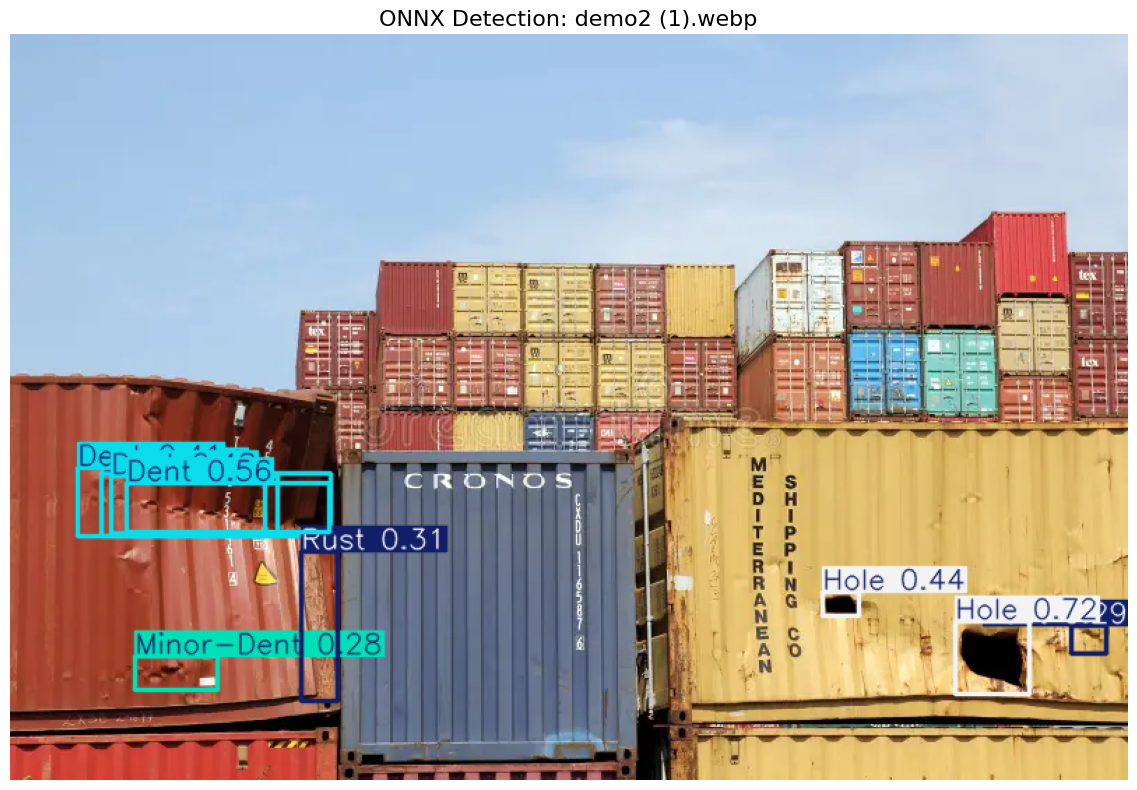

In [54]:
import os
import glob
from google.colab import files
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
from PIL import Image

# 1. Auto-Hunt for the ONNX file
print("🔍 Searching for your ONNX brain...")
onnx_files = glob.glob('/content/**/*.onnx', recursive=True)

if not onnx_files:
    print("❌ Error: Could not find any .onnx files! Did your session disconnect?")
else:
    # Grab the most likely ONNX file
    onnx_path = onnx_files[0]
    print(f"✅ Found and loaded ONNX model at: {onnx_path}\n")
    model = YOLO(onnx_path)

    # 2. Upload the Test Images
    print("👇 Click 'Choose Files' below and select your 3 test images:")
    uploaded = files.upload()

    num_images = len(uploaded)

    if num_images > 0:
        print("\n⚙️ Processing through ONNX Engine...\n")
        # Setup a dynamic plot size based on how many images you upload
        plt.figure(figsize=(12, 8 * num_images))

        for i, filename in enumerate(uploaded.keys()):
            img = Image.open(filename)

            # 3. The ONNX Inference (Keeping Jetson Nano settings)
            results = model.predict(source=img, conf=0.25, imgsz=416)

            # 4. Draw the boxes and plot
            res_plotted = results[0].plot()

            plt.subplot(num_images, 1, i + 1)
            plt.imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))
            plt.title(f"ONNX Detection: {filename}", fontsize=16)
            plt.axis('off')

            # Print a quick text summary for each image
            print(f"🖼️ Results for {filename}: Found {len(results[0].boxes)} issues.")
            if len(results[0].boxes) == 0:
                print("  - Clean container! No damage detected.")
            else:
                for box in results[0].boxes:
                    class_id = int(box.cls[0])
                    conf = float(box.conf[0])
                    print(f"  - {model.names[class_id]} (Confidence: {conf:.2f})")
            print("-" * 30)

        plt.tight_layout()
        plt.show()
    else:
        print("No images were uploaded. Try running the cell again!")

In [51]:
from ultralytics import YOLO
import os

# 1. Load your Universal ONNX Engine
# (Make sure this path points to your actual downloaded ONNX file in Colab)
onnx_path = '/content/runs/detect/jetson_v5s_perfect_finetune/weights/best.onnx'

if not os.path.exists(onnx_path):
    print("❌ Error: ONNX file not found! Double check your path.")
else:
    model = YOLO(onnx_path)
    print("✅ ONNX Model Loaded!")

    # 2. Run the Grader!
    # We point it to your YAML so it knows where the 'test' images and labels are
    print("\n📊 Grading the ONNX engine against the Test Set...")

    # split='test' tells it to use the images it has never seen before
    metrics = model.val(data='/content/clean_dataset/data.yaml', split='test', imgsz=416)

    # 3. Print the "Headline" Numbers clearly
    print("\n" + "="*30)
    print("🏆 THE FINAL SCORECARD 🏆")
    print("="*30)

    # metrics.box.map50 is the standard "Accuracy" equivalent for Object Detection
    print(f"Overall mAP50 (Accuracy):  {metrics.box.map50 * 100:.1f}%")
    print(f"Overall Precision:         {metrics.box.p.mean() * 100:.1f}%")
    print(f"Overall Recall:            {metrics.box.r.mean() * 100:.1f}%")
    print("="*30)

✅ ONNX Model Loaded!

📊 Grading the ONNX engine against the Test Set...
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Loading /content/runs/detect/jetson_v5s_perfect_finetune/weights/best.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.24.4 with CUDAExecutionProvider
Setting batch=1 input of shape (1, 3, 416, 416)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 13.5±13.7 MB/s, size: 79.7 KB)
val: Scanning /content/clean_dataset/test/labels... 128 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 128/128 278.1it/s 0.5s
val: New cache created: /content/clean_dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 128/128 41.3it/s 3.1s
                   all        128        327      0.486      0.454       0.45      0.333
               Deframe          7          7      0.116      0.143      0.186      0.174
                  Dent         79         88      0.72

In [52]:
print("\n🔍 THE AUTOPSY: Class-by-Class Breakdown")
print("-" * 40)

# We loop through the internal array of class scores
for i, class_idx in enumerate(metrics.box.ap_class_index):
    class_name = model.names[class_idx]

    # Grab the specific mAP50 for this class
    map50 = metrics.box.ap50[i] * 100

    # Print it out cleanly
    print(f"{class_name: <15}: {map50:.1f}% mAP50")

print("-" * 40)


🔍 THE AUTOPSY: Class-by-Class Breakdown
----------------------------------------
Loading /content/runs/detect/jetson_v5s_perfect_finetune/weights/best.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.24.4 with CUDAExecutionProvider
Deframe        : 18.6% mAP50
Loading /content/runs/detect/jetson_v5s_perfect_finetune/weights/best.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.24.4 with CUDAExecutionProvider
Dent           : 84.2% mAP50
Loading /content/runs/detect/jetson_v5s_perfect_finetune/weights/best.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.24.4 with CUDAExecutionProvider
Hole           : 25.1% mAP50
Loading /content/runs/detect/jetson_v5s_perfect_finetune/weights/best.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.24.4 with CUDAExecutionProvider
Minor-Dent     : 55.1% mAP50
Loading /content/runs/detect/jetson_v5s_perfect_finetune/weights/best.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.24.4 with CUDAExecutionProvider
Rust        

In [53]:
import numpy as np

# This uses the 'metrics' and 'model' objects already loaded in your Colab memory
print("\n📊 RECALCULATING OVERALL SCORE (Excluding 'Deframe')")
print("=" * 50)

valid_ap50_scores = []
valid_precision = []
valid_recall = []
classes_included = []

# Loop through the autopsy data
for i, class_idx in enumerate(metrics.box.ap_class_index):
    class_name = model.names[class_idx]

    # 🛑 THE FILTER: Skip 'Deframe' entirely
    if class_name == 'Deframe':
        continue

    # Save the scores for the good classes
    valid_ap50_scores.append(metrics.box.ap50[i])
    valid_precision.append(metrics.box.p[i])
    valid_recall.append(metrics.box.r[i])
    classes_included.append(class_name)

# Calculate the new averages
new_map50 = np.mean(valid_ap50_scores) * 100
new_precision = np.mean(valid_precision) * 100
new_recall = np.mean(valid_recall) * 100

print(f"✅ Classes Evaluated: {', '.join(classes_included)}")
print("-" * 50)
print(f"🌟 NEW Overall mAP50:     {new_map50:.1f}%")
print(f"📈 NEW Overall Precision: {new_precision:.1f}%")
print(f"📉 NEW Overall Recall:    {new_recall:.1f}%")
print("=" * 50)


📊 RECALCULATING OVERALL SCORE (Excluding 'Deframe')
Loading /content/runs/detect/jetson_v5s_perfect_finetune/weights/best.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.24.4 with CUDAExecutionProvider
Loading /content/runs/detect/jetson_v5s_perfect_finetune/weights/best.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.24.4 with CUDAExecutionProvider
Loading /content/runs/detect/jetson_v5s_perfect_finetune/weights/best.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.24.4 with CUDAExecutionProvider
Loading /content/runs/detect/jetson_v5s_perfect_finetune/weights/best.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.24.4 with CUDAExecutionProvider
Loading /content/runs/detect/jetson_v5s_perfect_finetune/weights/best.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.24.4 with CUDAExecutionProvider
✅ Classes Evaluated: Dent, Hole, Minor-Dent, Rust
--------------------------------------------------
🌟 NEW Overall mAP50:     51.6%
📈 NEW Overall Precision: 

In [55]:
from ultralytics import YOLO
from google.colab import files

# 1. Load your original PyTorch brain (Make sure this path is correct!)
model = YOLO('/content/runs/detect/jetson_v5s_perfect_finetune/weights/best.pt')

print("🔄 Building a brand new ONNX file with Opset 12 math...")

# 2. The Magic Export Command
# opset=12 forces the math to translate perfectly for the Jetson Nano
onnx_path = model.export(
    format='onnx',
    imgsz=416,
    dynamic=False,
    opset=12
)

print(f"\n✅ Success! Your Jetson-ready file is located at: {onnx_path}")

# 3. Download it to your computer
files.download(onnx_path)

🔄 Building a brand new ONNX file with Opset 12 math...
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
YOLOv5s summary (fused): 85 layers, 9,113,471 parameters, 0 gradients, 23.8 GFLOPs

PyTorch: starting from '/content/runs/detect/jetson_v5s_perfect_finetune/weights/best.pt' with input shape (1, 3, 416, 416) BCHW and output shape(s) (1, 9, 3549) (17.6 MB)

ONNX: starting export with onnx 1.21.0 opset 12...
ONNX: slimming with onnxslim 0.1.90...
ONNX: export success ✅ 4.0s, saved as '/content/runs/detect/jetson_v5s_perfect_finetune/weights/best.onnx' (34.9 MB)

Export complete (5.1s)
Results saved to /content/runs/detect/jetson_v5s_perfect_finetune/weights
Predict:         yolo predict task=detect model=/content/runs/detect/jetson_v5s_perfect_finetune/weights/best.onnx imgsz=416 
Validate:        yolo val task=detect model=/content/runs/detect/jetson_v5s_perfect_finetune/weights/best.onnx imgsz=416 data=/content/clean_dataset/data.yaml  
Visualize:

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [56]:
import os
import glob
from google.colab import files

# 1. Clean the landing zone
!rm -f *.zip
print("🚀 READY FOR THE PAYLOAD. Click 'Choose Files' below to upload your Holes ZIP:")

# 2. Upload the file
uploaded = files.upload()

# 3. Create a secure, isolated folder and unpack
dataset_path = '/content/holes_dataset'
!mkdir -p {dataset_path}

for filename in uploaded.keys():
    print(f"\n📦 Unpacking {filename} into {dataset_path}...")
    !unzip -q "{filename}" -d {dataset_path}

print("\n✅ Unpack complete. Initiating Data Reconnaissance...\n")

# ==========================================
# 4. THE RECONNAISSANCE SCRIPT
# ==========================================
print("-" * 45)

# Count the Images
images = glob.glob(f'{dataset_path}/**/*.jpg', recursive=True) + glob.glob(f'{dataset_path}/**/*.png', recursive=True)
print(f"📸 Total Images found: {len(images)}")

# Count the Labels
labels = glob.glob(f'{dataset_path}/**/*.txt', recursive=True)

# Filter out setup files like 'classes.txt'
labels = [l for l in labels if 'classes' not in l.lower() and 'readme' not in l.lower()]
print(f"📝 Total Label files found: {len(labels)}")

# Scan the Class IDs
found_classes = set()
missing_labels = 0

for label_file in labels:
    try:
        with open(label_file, 'r') as f:
            for line in f.readlines():
                data = line.strip().split()
                if data:
                    # The first number is the Class ID
                    found_classes.add(int(data[0]))
    except Exception as e:
        missing_labels += 1

print("-" * 45)
print(f"🏷️ Unique Class IDs found inside the labels: {list(found_classes)}")

if missing_labels > 0:
    print(f"⚠️ Warning: {missing_labels} label files were empty or unreadable.")
print("-" * 45)

🚀 READY FOR THE PAYLOAD. Click 'Choose Files' below to upload your Holes ZIP:


KeyboardInterrupt: 

In [58]:
import os
import glob
from google.colab import files

# 1. Clean the landing zone
!rm -f *.zip
print("🚀 READY FOR THE PAYLOAD. Click 'Choose Files' below to upload your Holes ZIP:")

# 2. Upload the file
uploaded = files.upload()

# 3. Create a secure, isolated folder and unpack
dataset_path = '/content/holes_dataset'
!mkdir -p {dataset_path}

for filename in uploaded.keys():
    print(f"\n📦 Unpacking {filename} into {dataset_path}...")
    !unzip -q "{filename}" -d {dataset_path}

print("\n✅ Unpack complete. Initiating Data Reconnaissance...\n")

# ==========================================
# 4. THE RECONNAISSANCE SCRIPT
# ==========================================
print("-" * 45)

# Count the Images
images = glob.glob(f'{dataset_path}/**/*.jpg', recursive=True) + glob.glob(f'{dataset_path}/**/*.png', recursive=True)
print(f"📸 Total Images found: {len(images)}")

# Count the Labels
labels = glob.glob(f'{dataset_path}/**/*.txt', recursive=True)

# Filter out setup files like 'classes.txt'
labels = [l for l in labels if 'classes' not in l.lower() and 'readme' not in l.lower()]
print(f"📝 Total Label files found: {len(labels)}")

# Scan the Class IDs
found_classes = set()
missing_labels = 0

for label_file in labels:
    try:
        with open(label_file, 'r') as f:
            for line in f.readlines():
                data = line.strip().split()
                if data:
                    # The first number is the Class ID
                    found_classes.add(int(data[0]))
    except Exception as e:
        missing_labels += 1

print("-" * 45)
print(f"🏷️ Unique Class IDs found inside the labels: {list(found_classes)}")

if missing_labels > 0:
    print(f"⚠️ Warning: {missing_labels} label files were empty or unreadable.")
print("-" * 45)

🚀 READY FOR THE PAYLOAD. Click 'Choose Files' below to upload your Holes ZIP:


Saving finetuningv3.zip to finetuningv3.zip

📦 Unpacking finetuningv3.zip into /content/holes_dataset...
replace /content/holes_dataset/data.yaml? [y]es, [n]o, [A]ll, [N]one, [r]ename: A

✅ Unpack complete. Initiating Data Reconnaissance...

---------------------------------------------
📸 Total Images found: 1278
📝 Total Label files found: 1278
---------------------------------------------
🏷️ Unique Class IDs found inside the labels: [0, 1, 2, 3, 4]
---------------------------------------------


In [59]:
!cat /content/holes_dataset/data.yaml

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 5
names: ['Deframe', 'Dent', 'Hole', 'Minor-Dent', 'Rust']

roboflow:
  workspace: aria-4ivto
  project: container-damage-detection-uekkr-plfdn
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/aria-4ivto/container-damage-detection-uekkr-plfdn/dataset/1

In [60]:
# 1. Merge the Training Data
!cp -rn /content/holes_dataset/train/images/* /content/clean_dataset/train/images/ 2>/dev/null || true
!cp -rn /content/holes_dataset/train/labels/* /content/clean_dataset/train/labels/ 2>/dev/null || true

# 2. Merge the Validation Data
!cp -rn /content/holes_dataset/valid/images/* /content/clean_dataset/valid/images/ 2>/dev/null || true
!cp -rn /content/holes_dataset/valid/labels/* /content/clean_dataset/valid/labels/ 2>/dev/null || true

# 3. Merge the Test Data (if any exists in the new zip)
!cp -rn /content/holes_dataset/test/images/* /content/clean_dataset/test/images/ 2>/dev/null || true
!cp -rn /content/holes_dataset/test/labels/* /content/clean_dataset/test/labels/ 2>/dev/null || true

print("✅ Merge complete! Your dataset is now supercharged.")

✅ Merge complete! Your dataset is now supercharged.


In [61]:
from ultralytics import YOLO

# 1. Load your champion brain (We build ON top of this!)
# Make sure this path points to the rescued PyTorch file we used earlier
model = YOLO('/content/runs/detect/jetson_v5s_perfect_finetune/weights/best.pt')

print("🚀 INITIATING HOLE-SPECIALIST FINE-TUNING SPRINT...")

# 2. Train on the newly merged dataset
results = model.train(
    data='/content/clean_dataset/data.yaml',
    epochs=20,                 # A quick 20-epoch sprint to learn the new holes
    imgsz=416,                 # Keep it optimized for the Jetson Nano
    batch=16,                  # Standard batch size
    name='jetson_v5s_hole_specialist' # Save it in a brand new folder
)

print("🎉 Sprint Complete! The model has evolved.")

🚀 INITIATING HOLE-SPECIALIST FINE-TUNING SPRINT...
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/clean_dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/runs/detect/jetson_v5s_perfect_finetune/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=jetson_v5s

In [62]:
from ultralytics import YOLO
from google.colab import files

# 1. Load the NEW Champion Brain
model = YOLO('/content/runs/detect/jetson_v5s_hole_specialist/weights/best.pt')

print("🔄 Forging the Final Jetson Engine (Opset 12)...")

# 2. Export! (Keeping imgsz=416 to match your training and live script)
onnx_path = model.export(
    format='onnx',
    imgsz=416,
    dynamic=False,
    opset=12
)

print(f"\n✅ Weapon secured! Downloading {onnx_path}")
files.download(onnx_path)

🔄 Forging the Final Jetson Engine (Opset 12)...
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
YOLOv5s summary (fused): 85 layers, 9,113,471 parameters, 0 gradients, 23.8 GFLOPs

PyTorch: starting from '/content/runs/detect/jetson_v5s_hole_specialist/weights/best.pt' with input shape (1, 3, 416, 416) BCHW and output shape(s) (1, 9, 3549) (17.6 MB)

ONNX: starting export with onnx 1.21.0 opset 12...
ONNX: slimming with onnxslim 0.1.90...
ONNX: export success ✅ 5.6s, saved as '/content/runs/detect/jetson_v5s_hole_specialist/weights/best.onnx' (34.9 MB)

Export complete (6.1s)
Results saved to /content/runs/detect/jetson_v5s_hole_specialist/weights
Predict:         yolo predict task=detect model=/content/runs/detect/jetson_v5s_hole_specialist/weights/best.onnx imgsz=416 
Validate:        yolo val task=detect model=/content/runs/detect/jetson_v5s_hole_specialist/weights/best.onnx imgsz=416 data=/content/clean_dataset/data.yaml  
Visualize:       https

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [63]:
import os
from google.colab import files

print("🚀 PREPARING BULK TEST ENVIRONMENT...")

# 1. Clean up any old test folders
!rm -rf /content/random_test_images
!mkdir -p /content/random_test_images

# 2. Upload the ZIP
print("👇 Click 'Choose Files' and upload your ZIP of 25 images:")
uploaded = files.upload()

# 3. Unpack
for filename in uploaded.keys():
    print(f"\n📦 Unpacking {filename}...")
    !unzip -q "{filename}" -d /content/random_test_images

print("\n✅ Images locked and loaded!")

🚀 PREPARING BULK TEST ENVIRONMENT...
👇 Click 'Choose Files' and upload your ZIP of 25 images:


Saving container_damage_test_images.zip to container_damage_test_images.zip

📦 Unpacking container_damage_test_images.zip...

✅ Images locked and loaded!


In [64]:
from ultralytics import YOLO
import shutil
from google.colab import files

# 1. Load your brand new Hole Specialist brain
model = YOLO('/content/runs/detect/jetson_v5s_hole_specialist/weights/best.pt')

print("🧠 Running high-speed bulk inference...")

# 2. Grade the entire folder at once
results = model.predict(
    source='/content/random_test_images',
    conf=0.4,       # Filter out weak guesses
    save=True,      # Tell it to draw and save the images
    project='/content/runs/detect',
    name='bulk_test_results' # Save them in this specific folder
)

print("✅ Grading complete! Packaging results for download...")

# 3. Zip up the graded images
shutil.make_archive('/content/graded_containers', 'zip', '/content/runs/detect/bulk_test_results')

# 4. Download to your computer
files.download('/content/graded_containers.zip')

🧠 Running high-speed bulk inference...



FileNotFoundError: No images or videos found in /content/random_test_images. Supported formats are:
images: {'jpeg', 'avif', 'heic', 'webp', 'tiff', 'png', 'jpeg2000', 'heif', 'bmp', 'tif', 'jp2', 'mpo', 'dng', 'jpg'}
videos: {'asf', 'm4v', 'webm', 'mpg', 'wmv', 'gif', 'mpeg', 'mp4', 'ts', 'mov', 'avi', 'mkv'}

In [65]:
import os
import glob
import shutil
from ultralytics import YOLO
from google.colab import files

# 1. THE PATHFINDER: Hunt down where the images are actually hiding
# This looks for any .jpg or .png anywhere inside the unzipped folder
search_pattern = '/content/random_test_images/**/*'
image_files = glob.glob(search_pattern + '.jpg', recursive=True) + \
              glob.glob(search_pattern + '.png', recursive=True) + \
              glob.glob(search_pattern + '.jpeg', recursive=True)

if not image_files:
    print("❌ ERROR: No images found! Double-check that your ZIP upload finished.")
else:
    # Find the folder that actually contains the files
    source_folder = os.path.dirname(image_files[0])
    print(f"🎯 TARGET ACQUIRED: Found {len(image_files)} images in: {source_folder}")

    # 2. LOAD THE NEW BRAIN
    # Pointing to your most recent fine-tuned specialist model
    model_path = '/content/runs/detect/jetson_v5s_hole_specialist/weights/best.pt'
    model = YOLO(model_path)

    print("🧠 INITIATING BULK INFERENCE...")

    # 3. RUN THE AI
    # This will create a folder at /content/runs/detect/bulk_test_results
    results = model.predict(
        source=source_folder,
        conf=0.35,      # Dropped slightly to 0.35 to catch more potential holes
        save=True,      # Saves the visual output (boxes + labels)
        project='/content/runs/detect',
        name='bulk_test_results',
        exist_ok=True   # Overwrites if you run it multiple times
    )

    # 4. PACKAGE AND DOWNLOAD
    print("📦 Packaging results into a ZIP...")
    output_zip = '/content/graded_containers_final'
    shutil.make_archive(output_zip, 'zip', '/content/runs/detect/bulk_test_results')

    print("🚀 STARTING DOWNLOAD...")
    files.download(f'{output_zip}.zip')

🎯 TARGET ACQUIRED: Found 25 images in: /content/random_test_images/container_damage_test_images
🧠 INITIATING BULK INFERENCE...

image 1/25 /content/random_test_images/container_damage_test_images/img5.jpg: 320x416 (no detections), 14.8ms
image 2/25 /content/random_test_images/container_damage_test_images/img_1.jpg: 320x416 1 Deframe, 1 Dent, 2 Rusts, 9.6ms
image 3/25 /content/random_test_images/container_damage_test_images/img_10.jpg: 320x416 1 Hole, 11.5ms
image 4/25 /content/random_test_images/container_damage_test_images/img_11.jpg: 288x416 3 Deframes, 3 Dents, 1 Hole, 1 Minor-Dent, 75.3ms
image 5/25 /content/random_test_images/container_damage_test_images/img_12.jpg: 416x416 2 Holes, 10.7ms
image 6/25 /content/random_test_images/container_damage_test_images/img_13.jpg: 256x416 2 Rusts, 10.7ms
image 7/25 /content/random_test_images/container_damage_test_images/img_14.jpg: 256x416 1 Deframe, 1 Rust, 9.3ms
image 8/25 /content/random_test_images/container_damage_test_images/img_15.jpg:

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📸 UPLOAD TEST: Select a single container image to analyze...


Saving img_20.jpg to img_20.jpg

image 1/1 /content/img_20.jpg: 320x416 (no detections), 14.0ms
Speed: 1.3ms preprocess, 14.0ms inference, 0.8ms postprocess per image at shape (1, 3, 320, 416)


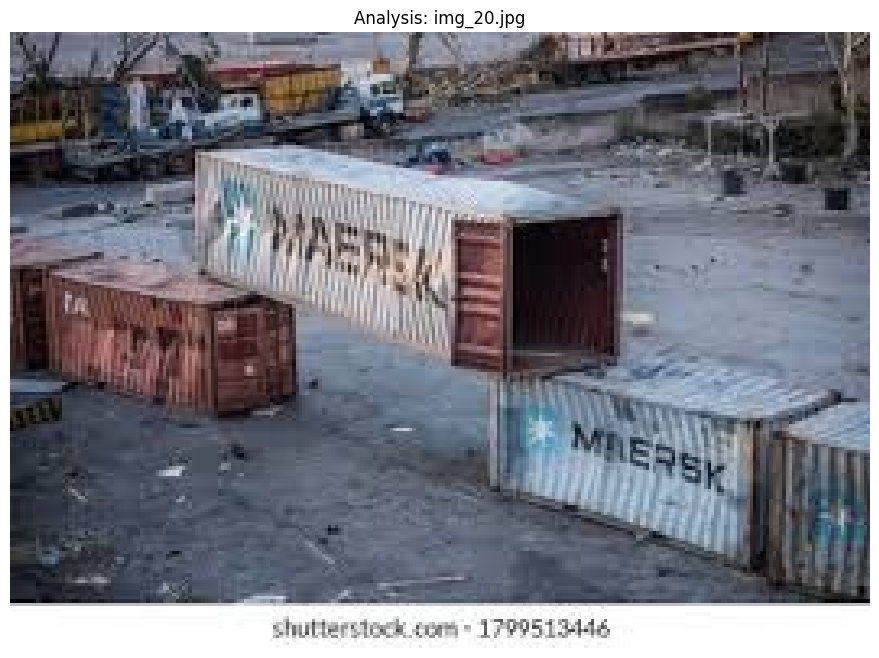


🔍 DETECTIONS FOUND:
✅ No damage detected. Container looks clean!


In [69]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
from google.colab import files
from PIL import Image

# 1. LOAD THE HOLE SPECIALIST BRAIN
model_path = '/content/runs/detect/jetson_v5s_hole_specialist/weights/best.pt'
model = YOLO(model_path)

# 2. UPLOAD THE IMAGE
print("📸 UPLOAD TEST: Select a single container image to analyze...")
uploaded = files.upload()

for filename in uploaded.keys():
    # 3. RUN INFERENCE
    # We use a slightly lower confidence (0.3) for single tests to see everything the AI "thinks" might be damage
    results = model.predict(source=filename, conf=0.3, imgsz=416, save=False)

    # 4. PLOT AND DISPLAY
    # This grabs the image with boxes drawn on it
    res_plotted = results[0].plot()

    # Convert BGR (OpenCV) to RGB (Matplotlib/PIL)
    res_rgb = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 8))
    plt.imshow(res_rgb)
    plt.axis('off')
    plt.title(f"Analysis: {filename}")
    plt.show()

    # 5. PRINT SUMMARY
    print(f"\n🔍 DETECTIONS FOUND:")
    if len(results[0].boxes) == 0:
        print("✅ No damage detected. Container looks clean!")
    for box in results[0].boxes:
        class_id = int(box.cls[0])
        conf = float(box.conf[0])
        print(f"📍 {model.names[class_id]}: {conf*100:.1f}% Confidence")

In [71]:
# --- ADD THIS PART TO FIX THE NAMEERROR ---
# This looks at the files you uploaded in the previous cell
import os

# Get the name of the file you just uploaded
uploaded_files = [f for f in os.listdir('/content') if f.endswith(('.mp4', '.mov', '.avi'))]

if not uploaded_files:
    print("❌ No video found! Please run the upload cell first.")
else:
    video_path = f'/content/{uploaded_files[0]}'
    print(f"🎬 Found video: {video_path}")

    # --- NOW RUN THE REST ---
    report, total_analyzed = process_storage_video(video_path)

    print("\n" + "="*40)
    print("📦 STORAGE FACILITY INSPECTION REPORT")
    print("="*40)
    # ... (rest of your print code)

❌ No video found! Please run the upload cell first.
